In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error
from qiskit.quantum_info import DensityMatrix, state_fidelity, concurrence

In [5]:
# initializing and generating ideal state
def create_ideal_bell_state():
    qc = QuantumCircuit(2)
    qc.h(0)        # Superposition on Qubit 0
    qc.cx(0, 1)    # Entanglement via CNOT
    return qc

ideal_circuit = create_ideal_bell_state()
ideal_density_matrix = DensityMatrix(ideal_circuit)

In [8]:
# wireless noise modeling functions
# depolarizing noise model
def get_depolarizing_noise_model(p):
    noise_model = NoiseModel()
    error_1q = depolarizing_error(p,1)
    error_2q = depolarizing_error(p,2)

    noise_model.add_all_qubit_quantum_error(error_1q, ['h'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    return noise_model


In [10]:
# amplitude damping noise model
def get_amplitude_damping_noise_model(gamma):
    noise_model = NoiseModel()
    error_1q = amplitude_damping_error(gamma)
    error_2q = error_1q.tensor(error_1q)

    noise_model.add_all_qubit_quantum_error(error_1q, ['h'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    return noise_model

In [11]:
# simulation and matric calculation 
def simulate_and_calculate(noise_model):
    sim = AerSimulator(method='density_matrix')

    # saving the density matrix before wavefunction collapse
    qc_noisy = create_ideal_bell_state()
    qc_noisy.save_density_matrix()

    # transpile and execute
    t_qc = transpile(qc_noisy,sim)
    result = sim.run(t_qc, noise_model=noise_model, shots=1024).result()

    # noise density matrix
    noisy_density_matrix = result.data()['density_matrix']

    # calculating mathematical metrics
    fidelity = state_fidelity(ideal_density_matrix, noisy_density_matrix)
    conc = concurrence(noisy_density_matrix)

    return fidelity, conc    

In [12]:
# main execution
noise_parameters = np.linspace(0.0, 1.0, 20) # simulate from 0% to 100% noise

depol_fidelity = []
depol_concurrences = []
amp_fidelity = []
amp_concurrences = []

for p in noise_parameters:
    # testing depolarizing channel
    depol_noise = get_depolarizing_noise_model(p)
    f, c = simulate_and_calculate(depol_noise)
    depol_fidelity.append(f)
    depol_concurrences.append(c)

    # testing amplitude damping channel
    amp_noise = get_amplitude_damping_noise_model(p)
    f_amp, c_amp = simulate_and_calculate(amp_noise)
    amp_fidelity.append(f_amp)
    amp_concurrences.append(c_amp)

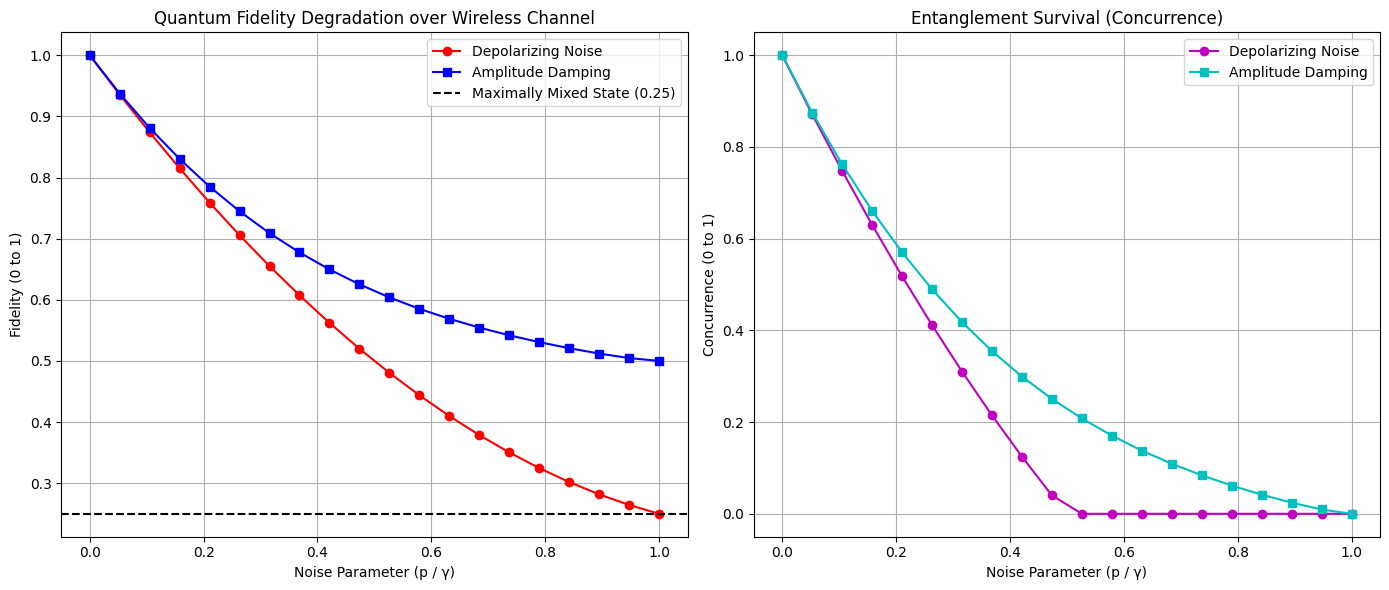

In [13]:
# outputs and graphs
plt.figure(figsize=(14,6))

# fidelity vs noise
plt.subplot(1, 2, 1)
plt.plot(noise_parameters, depol_fidelity, 'r-o', label='Depolarizing Noise')
plt.plot(noise_parameters, amp_fidelity, 'b-s', label='Amplitude Damping')
plt.axhline(y=0.25, color='k', linestyle='--', label='Maximally Mixed State (0.25)')
plt.title('Quantum Fidelity Degradation over Wireless Channel')
plt.xlabel('Noise Parameter (p / γ)')
plt.ylabel('Fidelity (0 to 1)')
plt.legend()
plt.grid(True)

# concurrence vs noise
plt.subplot(1, 2, 2)
plt.plot(noise_parameters, depol_concurrences, 'm-o', label='Depolarizing Noise')
plt.plot(noise_parameters, amp_concurrences, 'c-s', label='Amplitude Damping')
plt.title('Entanglement Survival (Concurrence)')
plt.xlabel('Noise Parameter (p / γ)')
plt.ylabel('Concurrence (0 to 1)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()